IMPORTAÇÃO DAS BIBLIOTECA NECESSÁRIAS

In [1]:
#bibliotecas para processamento de dados
import pandas

#bibliotecas para transformação de dados
from sklearn.decomposition import PCA

#biblitecas para clustering
from sklearn.cluster import KMeans

#biblioteca para visualização de dados
import matplotlib.pyplot as pyplot  

INGESTÃO/IMPORTAÇÃO DOS DADOS

In [2]:
#importação do arquivo com os dados de sementes de trigo
arquivo = "seeds-data.csv"
dados = pandas.read_csv(arquivo, sep=",")

#exibe uma amostra dos dados
display(dados.head(10))

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,0
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,0
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,0
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,0
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,0


PRÉ-PROCESSAMENTO DOS DADOS
- Remover valores ausentes (nulos) e quaisquer linhas que possam comprometer o processo de modelagem de dados

In [3]:
#verifica se os tipos de dados estão corretos
print(dados.dtypes)

#armazena a quantidade original de dados
originais = len(dados)

#remove linhas com valores ausentes
filtrados = dados.dropna()

#armazena a quantidade de dados após a remoção dos valores ausentes
finais = len(filtrados)

#calcula a quantidade de linhas removidas
eliminados = originais - filtrados

#calcula a quantidade de linhas removida
eliminados = originais - finais
percentual = (eliminados/originais)*100

#exibe os resultados do pré processamento dos dados
print(f"original: {originais}")
print(f"pós filtragem: {finais}")
print(f"percentual de remoção: {percentual:.2f}%")


area                     float64
perimeter                float64
compactness              float64
kernel_length            float64
kernel_width             float64
asymmetry_coefficient    float64
groove_length            float64
species                    int64
dtype: object
original: 210
pós filtragem: 210
percentual de remoção: 0.00%


REDUÇÃO DE DIMENSIONALIDADE
diminuir qtd de variáveis

In [4]:
#seleciona as variáveis de interesse
X = dados.drop('species', axis=1)

#aplica a analise de componentes principais (PCA)
PCASeeds = PCA(n_components=2)
XPCA = PCASeeds.fit_transform(X)

#cria um novo dataframe com os dois componentes principais
dados = pandas.DataFrame(XPCA, columns=['PCA-1', 'PCA-2'])

#exibe os dados reduzidos para duas dimensões
print(dados.head(10))

      PCA-1     PCA-2
0  0.663448 -1.417321
1  0.315667 -2.689229
2 -0.660499 -1.131506
3 -1.055276 -1.621190
4  1.619999 -2.183384
5 -0.476938 -1.336494
6 -0.184835 -0.150364
7 -0.780630 -1.129799
8  2.282108 -1.360017
9  1.978541 -1.494688


AGRUPAMENTO DOS DADOS (K-MEANS)
não supervisionado; clusters por similaridades

In [5]:
#define o número de clusters (K)
kmeans = KMeans(n_clusters=3, random_state=42)

#executa o agrupamento dos dados
dados["Cluster"] = kmeans.fit_predict(XPCA)

#exibe os dados com o cluster
display(dados)

,PCA-1,PCA-2,Cluster
0,0.663448,-1.417321,2
1,0.315667,-2.689229,2
2,-0.660499,-1.131506,2
3,-1.055276,-1.621190,2
4,1.619999,-2.183384,2
...,...,...,...
205,-3.041872,-0.473126,1
206,-4.109063,0.109341,1
207,-2.500034,4.307965,1
208,-3.332079,-0.525290,1


VISUALIZAÇÃO DOS GRÁFICOS

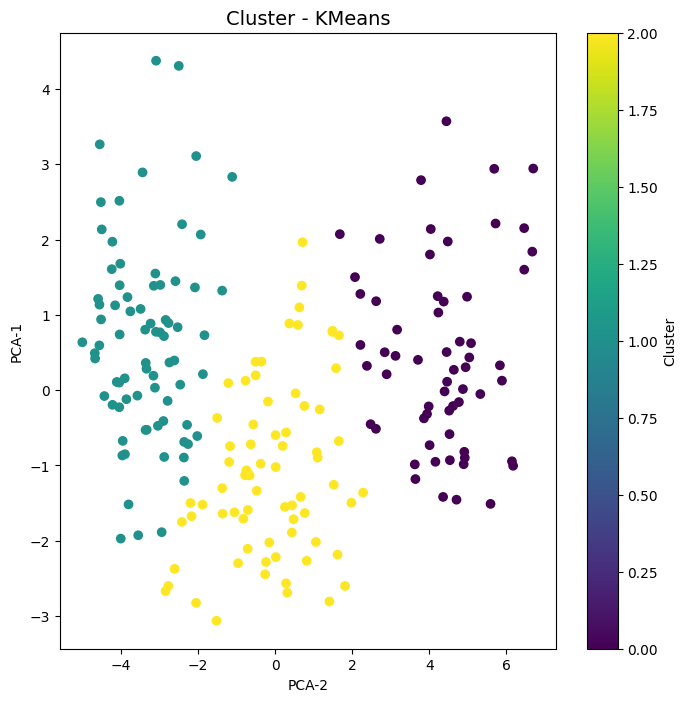

In [6]:
#cria um gráfico de disperção com os clusters
pyplot.figure(figsize=(8, 8))
pyplot.scatter(dados['PCA-1'], dados['PCA-2'], c=dados['Cluster'], cmap='viridis')
pyplot.title("Cluster - KMeans", fontsize=14)
pyplot.ylabel("PCA-1")
pyplot.xlabel("PCA-2")
pyplot.colorbar(label="Cluster")
pyplot.show()